In [2]:
# Section 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import umap.umap_ as umap

In [8]:
# import sys
# !{sys.executable} -m pip install umap-learn

In [3]:
# Section 2 — Load ML features + K-Means labels

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

ML_FEATURES_PATH = PROCESSED_DATA_DIR / "customer_features_ml.parquet"
KMEANS_PATH = PROCESSED_DATA_DIR / "customer_segments_kmeans.parquet"

ml_df = pd.read_parquet(ML_FEATURES_PATH)
kmeans_df = pd.read_parquet(KMEANS_PATH)

feature_columns = [
    "recency_days",
    "log_frequency",
    "log_monetary",
    "log_average_order_value",
    "log_avg_items_per_order",
    "log_unique_products",
    "purchase_span_days",
    "return_order_share",
    "return_value_share",
    "has_return"
]

X = ml_df[feature_columns].copy()
kmeans_labels = kmeans_df["cluster"].values

print("X:", X.shape)
print("Labels:", len(kmeans_labels))

X: (5878, 10)
Labels: 5878


In [4]:
# Section 3 — PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_

print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])
print("Total:", explained_variance.sum())

PC1: 0.45304369282940515
PC2: 0.19208088022480208
Total: 0.6451245730542072


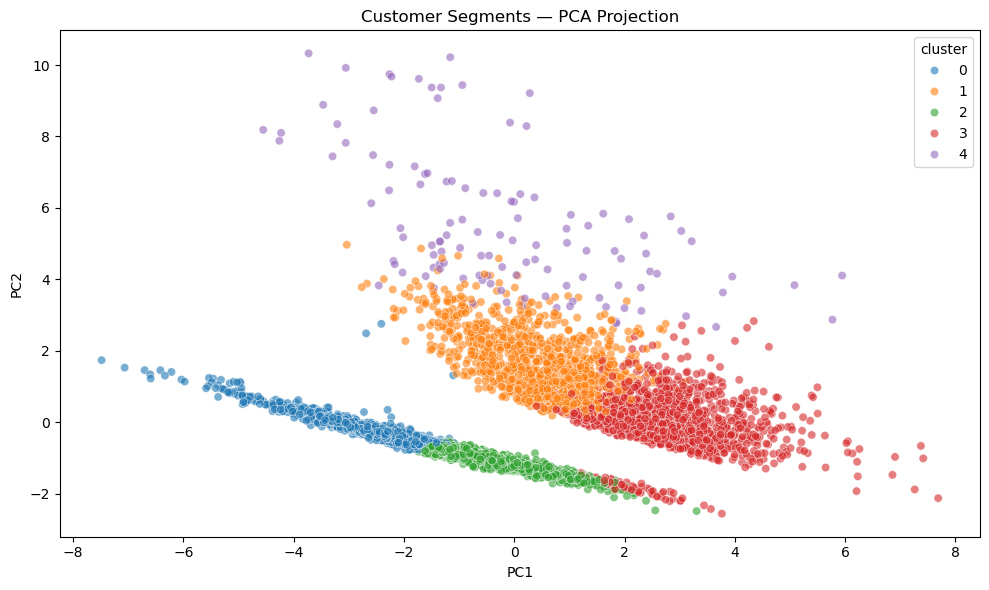

In [5]:
# Section 4 — PCA visualization
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": kmeans_labels
})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("Customer Segments — PCA Projection")
plt.tight_layout()
plt.show()

In [6]:
%pip install -U scikit-learn umap-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\ProgramData\anaconda3\python.exe -m pip install --upgrade pip


In [7]:
# Section 5 — UMAP
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X)

print("UMAP shape:", X_umap.shape)

C:\Users\arman\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (5878, 2)


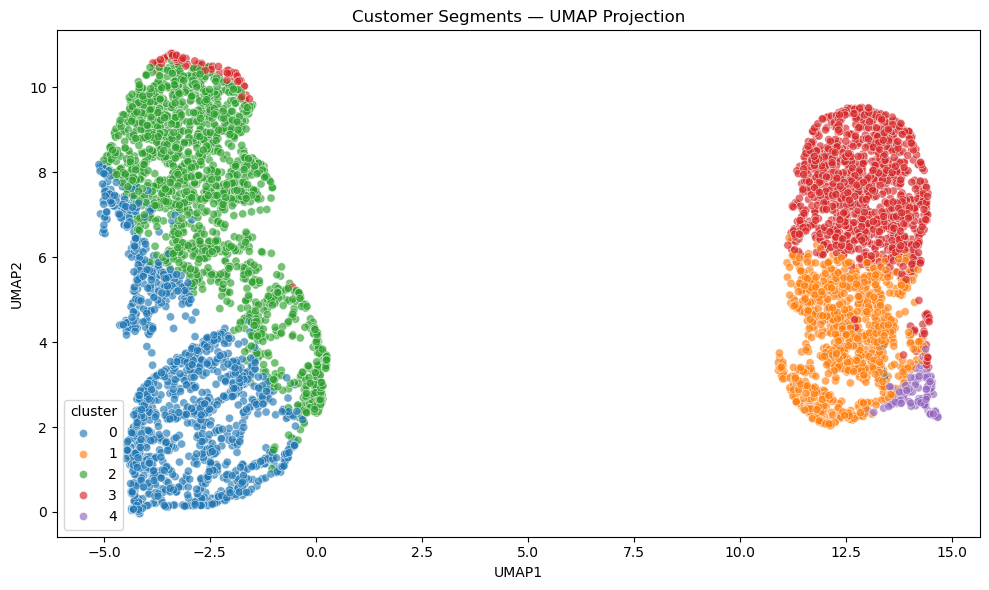

In [8]:
# Section 6 — UMAP visualization
umap_df = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "cluster": kmeans_labels
})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="cluster",
    palette="tab10",
    alpha=0.65,
    s=35
)

plt.title("Customer Segments — UMAP Projection")
plt.tight_layout()
plt.show()